### Initialization

In [1]:
import tensorflow as tf

# Set the seed for reproducibility
SEED = 42
INPUT_SHAPE = 42
NUM_CORES = 8
num_classes = 5

2025-08-17 09:42:46.008084: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-17 09:42:46.015770: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755434566.024865   71480 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755434566.027716   71480 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755434566.034949   71480 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
gpus = tf.config.list_physical_devices('GPU')
print("GPU Available:", gpus)
print("cuDNN Enabled:", tf.test.is_built_with_cuda())

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Set the number of intra-op and inter-op threads
tf.config.threading.set_intra_op_parallelism_threads(NUM_CORES)
tf.config.threading.set_inter_op_parallelism_threads(NUM_CORES)
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
cuDNN Enabled: True


### Load models

In [3]:
import os
from tensorflow.keras import layers, models, backend as K

class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = K.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# Path to the saved models
model_dir = "../../models/vae/"

# Load the encoder
# We pass the custom layer in the `custom_objects` dictionary
encoder = models.load_model(
    os.path.join(model_dir, "m1_encoder_mitosis.keras"),
    custom_objects={"Sampling": Sampling}
)

# Load the decoder
decoder = models.load_model(os.path.join(model_dir, "m1_decoder_mitosis.keras"))

print("Encoder and Decoder models loaded successfully!")
# encoder.summary()
# decoder.summary()

I0000 00:00:1755434567.238920   71480 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 17182 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:01:00.0, compute capability: 8.6


Encoder and Decoder models loaded successfully!


### Building the M2 Classifier

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import LeakyReLU, BatchNormalization

def build_classifier(num_classes=num_classes):
    """
    Builds a deep convolutional classifier suitable for 200x200 images.
    
    Args:
        num_classes (int): The number of output classes.
        
    Returns:
        A Keras Model for the classifier.
    """
    inputs = layers.Input(shape=(200, 200, 1))
    
    # Block 1: 200x200 -> 100x100
    x = layers.Conv2D(32, 5, padding='same')(inputs)
    x = LeakyReLU(alpha=0.2)(x)
    x = BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    
    # Block 2: 100x100 -> 50x50
    x = layers.Conv2D(64, 5, padding='same')(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    
    # Block 3: 50x50 -> 25x25
    x = layers.Conv2D(128, 3, padding='same')(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)

    # Block 4 (New): 25x25 -> 12x12
    x = layers.Conv2D(256, 3, padding='same')(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    
    # Block 5 (New): 12x12 -> 6x6
    x = layers.Conv2D(512, 3, padding='same')(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    
    # Fully Connected Head
    x = layers.Flatten()(x)
    x = layers.Dense(512)(x) # Increased capacity
    x = LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.5)(x)
    
    x = layers.Dense(256)(x) # Increased capacity
    x = LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.5)(x)
    
    x = layers.Dense(128)(x) # Increased capacity
    x = LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.5)(x)

    # Output layer
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    classifier = models.Model(inputs, outputs, name="classifier")
    return classifier

# Instantiate the new, deeper classifier
classifier = build_classifier()
# classifier.summary()

/home/nicolas/Documentos/UTN/INA/giar_ina_dev/.venv/lib/python3.12/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


### Definition of the model

In [5]:
import tensorflow as tf
from tensorflow.keras import models, metrics
from tensorflow.keras.losses import SparseCategoricalCrossentropy, BinaryCrossentropy

class CustomLoss(tf.keras.losses.Loss):
    def __init__(self, y, z, name="custom_loss"):
        super().__init__(name=name)
        # Weights
        self.y = y
        self.z = z

        # MAE
        self.mae_loss_fn = tf.keras.losses.MeanAbsoluteError()

    # SSIM loss
    def ssim_loss(self, y_true, y_pred):
        ssim = (1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))) / 2
        return ssim

    def call(self, y_true, y_pred):
        mae_loss = self.mae_loss_fn(y_true, y_pred)
        ssim = self.ssim_loss(y_true, y_pred)
        return self.y * mae_loss + self.z * ssim

class SemiSupervisedVAE(models.Model):
    def __init__(self, encoder, decoder, classifier, reconstruction_loss_fn, alpha=0.1, beta=1.0, **kwargs):
        super(SemiSupervisedVAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.classifier = classifier
        self.alpha = alpha
        self.beta = beta  # Weight for the KL divergence term
        self.num_classes = self.classifier.output_shape[-1]
        
        self.recon_loss_fn = reconstruction_loss_fn
        self.bce_loss = BinaryCrossentropy(reduction=tf.keras.losses.Reduction.NONE)
        self.scce_loss = SparseCategoricalCrossentropy(reduction=tf.keras.losses.Reduction.NONE)

    def call(self, inputs):
        return self.classifier(inputs)
        
    def _calculate_vae_loss(self, x):
        """Calculates the VAE loss (reconstruction + weighted KL divergence)."""
        z_mean, z_log_var, z = self.encoder(x)
        reconstruction = self.decoder(z)
        # recon_loss = tf.reduce_sum(self.bce_loss(x, reconstruction), axis=(1, 2))
        
        recon_loss = self.recon_loss_fn(x, reconstruction)
        recon_loss = recon_loss * (INPUT_SHAPE * INPUT_SHAPE)

        kl_loss = -0.5 * tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        total_loss = tf.reduce_mean(recon_loss + self.beta * kl_loss)
        return total_loss, recon_loss, kl_loss

    def _calculate_clf_labeled_loss(self, x, y):
        """Calculates ONLY the scaled supervised classification loss."""
        y_pred = self.classifier(x)
        clf_loss = tf.reduce_mean(self.scce_loss(y, y_pred))
        return self.alpha * tf.cast(tf.shape(x)[0], tf.float32) * clf_loss

    def _calculate_clf_unlabeled_loss(self, x):
        """Calculates ONLY the self-taught classification loss."""
        y_pred = self.classifier(x)
        
        unlabeled_clf_loss = 0
        for i in range(self.num_classes):
            y_i = tf.fill((tf.shape(x)[0], 1), float(i))
            unlabeled_clf_loss += y_pred[:, i] * self.scce_loss(y_i, y_pred)
        
        entropy = -tf.reduce_sum(y_pred * tf.math.log(y_pred + 1e-10), axis=1)
        return tf.reduce_mean(unlabeled_clf_loss - entropy)

    def train_step(self, data):
        labeled_data, unlabeled_data = data
        x_labeled, y_labeled = labeled_data
        x_unlabeled = unlabeled_data

        with tf.GradientTape() as tape:
            # --- Efficient Loss Calculation ---
            # 1. Calculate VAE loss for both batches (once each)
            vae_loss_labeled, recon_loss_labeled, kl_loss_labeled = self._calculate_vae_loss(x_labeled)
            vae_loss_unlabeled, recon_loss_unlabeled, kl_loss_unlabeled = self._calculate_vae_loss(x_unlabeled)
            
            # 2. Calculate classification losses
            clf_loss_labeled = self._calculate_clf_labeled_loss(x_labeled, y_labeled)
            clf_loss_unlabeled = self._calculate_clf_unlabeled_loss(x_unlabeled)

            # 3. Combine all components for the total loss
            total_loss = (vae_loss_labeled + clf_loss_labeled) + \
                         (vae_loss_unlabeled + clf_loss_unlabeled)
            
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        # Convert the per-sample loss tensors to scalar means before logging.
        avg_recon_loss = tf.reduce_mean(recon_loss_labeled) + tf.reduce_mean(recon_loss_unlabeled)
        avg_kl_loss = tf.reduce_mean(kl_loss_labeled) + tf.reduce_mean(kl_loss_unlabeled)
        total_clf_loss = clf_loss_labeled + clf_loss_unlabeled

        # Return the scalar metrics for Keras logging
        return {
            "loss": total_loss,
            "recon_loss": avg_recon_loss,
            "kl_loss": avg_kl_loss,
            "clf_loss": total_clf_loss,
        }

### Load data

In [6]:
import tensorflow as tf
import os
import glob

IMAGES_UNLABELED_PATH = "/home/nicolas/Documentos/UTN/INA/giar_ina_dev/media/cropped_images/dividing_rf"
# IMAGES_UNLABELED_PATH = "/home/nicolas/Documentos/UTN/INA/giar_ina_dev/media/cropped_images/classification/train"
IMAGES_LABELED_PATH = "/home/nicolas/Documentos/UTN/INA/giar_ina_dev/media/cropped_images/classification/test_v2"
INPUT_SHAPE = 200
BATCH_SIZE = 64

In [7]:
def load_and_preprocess_image(path):
    """Loads and preprocesses a single image."""
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=1, expand_animations=False)
    image = tf.image.resize(image, [INPUT_SHAPE, INPUT_SHAPE])
    image = tf.cast(image, tf.float32) / 255.0
    return image

# Get file paths
unlabeled_files = glob.glob(os.path.join(IMAGES_UNLABELED_PATH, '*'))

# Create the dataset
unlabeled_dataset_m2 = tf.data.Dataset.from_tensor_slices(unlabeled_files)
unlabeled_dataset_m2 = unlabeled_dataset_m2.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
unlabeled_dataset_m2 = unlabeled_dataset_m2.shuffle(buffer_size=len(unlabeled_files)).batch(BATCH_SIZE).repeat()

In [8]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

# --- 1. Manually Collect File Paths and Labels ---

print("Manually collecting labeled file paths and labels...")
labeled_file_paths = []
labeled_labels = []
class_names = sorted([d for d in os.listdir(IMAGES_LABELED_PATH) if os.path.isdir(os.path.join(IMAGES_LABELED_PATH, d))])
class_map = {name: i for i, name in enumerate(class_names)}

for class_name in class_names:
    class_dir = os.path.join(IMAGES_LABELED_PATH, class_name)
    for filepath in os.listdir(class_dir):
        labeled_file_paths.append(os.path.join(class_dir, filepath))
        labeled_labels.append(class_map[class_name])

# Convert to NumPy arrays for scikit-learn
labeled_file_paths = np.array(labeled_file_paths)
labeled_labels = np.array(labeled_labels)
print(f"Found {len(labeled_file_paths)} labeled images belonging to {len(class_names)} classes.")


# --- 2. Perform a Stratified Split ---

print("Performing stratified split...")
train_files, test_files, train_labels, test_labels = train_test_split(
    labeled_file_paths,
    labeled_labels,
    test_size=0.2,
    stratify=labeled_labels, # This ensures the split is balanced!
    random_state=42
)
print(f"Training samples: {len(train_files)}, Test samples: {len(test_files)}")


# --- 3. Create tf.data.Dataset Objects ---

def load_and_normalize(path, label):
    """Reads image from path, preprocesses it, and passes label through."""
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=1, expand_animations=False)
    image = tf.image.resize(image, [INPUT_SHAPE, INPUT_SHAPE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Create the training dataset for the labeled part of M2
labeled_train_ds = tf.data.Dataset.from_tensor_slices((train_files, train_labels))
labeled_train_ds = labeled_train_ds.shuffle(buffer_size=len(train_files))
labeled_train_ds = labeled_train_ds.map(load_and_normalize, num_parallel_calls=tf.data.AUTOTUNE)
labeled_train_ds = labeled_train_ds.batch(BATCH_SIZE).repeat() # Add repeat for M2 training
labeled_train_ds = labeled_train_ds.prefetch(tf.data.AUTOTUNE)

# Create the test dataset for final evaluation
labeled_test_ds = tf.data.Dataset.from_tensor_slices((test_files, test_labels))
labeled_test_ds = labeled_test_ds.map(load_and_normalize, num_parallel_calls=tf.data.AUTOTUNE)
labeled_test_ds = labeled_test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Manually collecting labeled file paths and labels...
Found 1243 labeled images belonging to 5 classes.
Performing stratified split...
Training samples: 994, Test samples: 249


In [9]:
# Create the final combined dataset for training
ss_train_dataset = tf.data.Dataset.zip((labeled_train_ds, unlabeled_dataset_m2))
ss_train_dataset = ss_train_dataset.prefetch(tf.data.AUTOTUNE)

### Training

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='clf_loss',      # The metric to monitor
    mode='min',
    patience=10,             # Number of epochs to wait for improvement
    verbose=1,               # Print a message when stopping
    restore_best_weights=True # Restore weights from the best epoch
)

lr_scheduler = ReduceLROnPlateau(
    monitor='clf_loss',   # The metric to monitor
    mode='min',
    factor=0.2,           # Factor by which to reduce the learning rate (new_lr = lr * factor)
    patience=5,           # Number of epochs to wait for improvement
    verbose=1,            # Print a message when the LR is updated
    min_lr=1e-7            # The minimum learning rate
)

callbacks = [early_stopping, lr_scheduler]

In [11]:
# --- Instantiate and Compile the Combined Model ---
custom_recon_loss = CustomLoss(y=0.17, z=0.83)

ss_vae = SemiSupervisedVAE(encoder, decoder, classifier, reconstruction_loss_fn=custom_recon_loss, alpha=1, beta=2) #0.5 * len(unlabeled_files)
ss_vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4))

# Calculate steps per epoch
steps_per_epoch = len(unlabeled_files) // BATCH_SIZE

# Now you can train the SemiSupervisedVAE
history = ss_vae.fit(
    ss_train_dataset, 
    epochs=20, 
    steps_per_epoch=steps_per_epoch,
    callbacks=callbacks # Pass the list of callbacks here
)

Epoch 1/20


I0000 00:00:1755434572.647169   71631 cuda_dnn.cc:529] Loaded cuDNN version 90701


46/46 ━━━━━━━━━━━━━━━━━━━━ 20s 335ms/step - clf_loss: 94.1550 - kl_loss: 67.9157 - loss: 13948.3955 - recon_loss: 13718.4092 - learning_rate: 1.0000e-04
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 16s 337ms/step - clf_loss: 87.5519 - kl_loss: 74.8151 - loss: 13776.5811 - recon_loss: 13539.3994 - learning_rate: 1.0000e-04
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 15s 336ms/step - clf_loss: 75.1914 - kl_loss: 77.7350 - loss: 13755.7598 - recon_loss: 13525.0986 - learning_rate: 1.0000e-04
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 15s 330ms/step - clf_loss: 64.5509 - kl_loss: 81.4349 - loss: 13569.9902 - recon_loss: 13342.5693 - learning_rate: 1.0000e-04
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 15s 332ms/step - clf_loss: 55.2953 - kl_loss: 84.5270 - loss: 13511.2227 - recon_loss: 13286.8740 - learning_rate: 1.0000e-04
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 15s 332ms/step - clf_loss: 47.4622 - kl_loss: 86.8314 - loss: 13429.5605 - recon_loss: 13208.4355 - learning_rate: 1.0000e-04
Epoch 7/20
46/46 ━━━━━━━━━━

In [12]:
import os

# Define a directory to save the final models
final_model_dir = "../../models/vae"
os.makedirs(final_model_dir, exist_ok=True)

print("Saving the final trained models...")

# Access each component from the trained ss_vae object and save it
ss_vae.encoder.save(os.path.join(final_model_dir, "final_encoder.keras"))
ss_vae.decoder.save(os.path.join(final_model_dir, "final_decoder.keras"))
ss_vae.classifier.save(os.path.join(final_model_dir, "final_classifier.keras"))

print(f"Models saved successfully to '{final_model_dir}' directory.")

Saving the final trained models...
Models saved successfully to '../../models/vae' directory.


In [13]:
# import os
# import tensorflow as tf
# from tensorflow.keras import models, layers, backend as K

# # 1. You MUST redefine any custom objects before loading
# class Sampling(layers.Layer):
#     """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""
#     def call(self, inputs):
#         z_mean, z_log_var = inputs
#         batch = tf.shape(z_mean)[0]
#         dim = tf.shape(z_mean)[1]
#         epsilon = K.random_normal(shape=(batch, dim))
#         return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# # Define the path to your saved models
# final_model_dir = "../../models/vae"

# # 2. Load the encoder, providing the custom layer in `custom_objects`
# encoder = models.load_model(
#     os.path.join(final_model_dir, "final_encoder.keras"),
#     custom_objects={"Sampling": Sampling}
# )

# # 3. Load the decoder and classifier (they have no custom layers)
# decoder = models.load_model(os.path.join(final_model_dir, "final_decoder.keras"))
# classifier = models.load_model(os.path.join(final_model_dir, "final_classifier.keras"))

# print("\nAll models loaded successfully!")

# # Verify by checking the summaries
# print("\nEncoder Summary:")
# encoder.summary()
# print("\nClassifier Summary:")
# classifier.summary()

In [14]:
# --- Evaluate the classifier's performance ---
print("\nEvaluating the classifier on the test set...")

# COMPILE the classifier before evaluating it
classifier.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

# Pass the labeled test dataset directly to evaluate()
results = classifier.evaluate(labeled_test_ds, verbose=1)

print(f"\nTest Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1] * 100:.2f}%")


Evaluating the classifier on the test set...
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5857 - loss: 4.4266

Test Loss: 4.2755
Test Accuracy: 59.44%


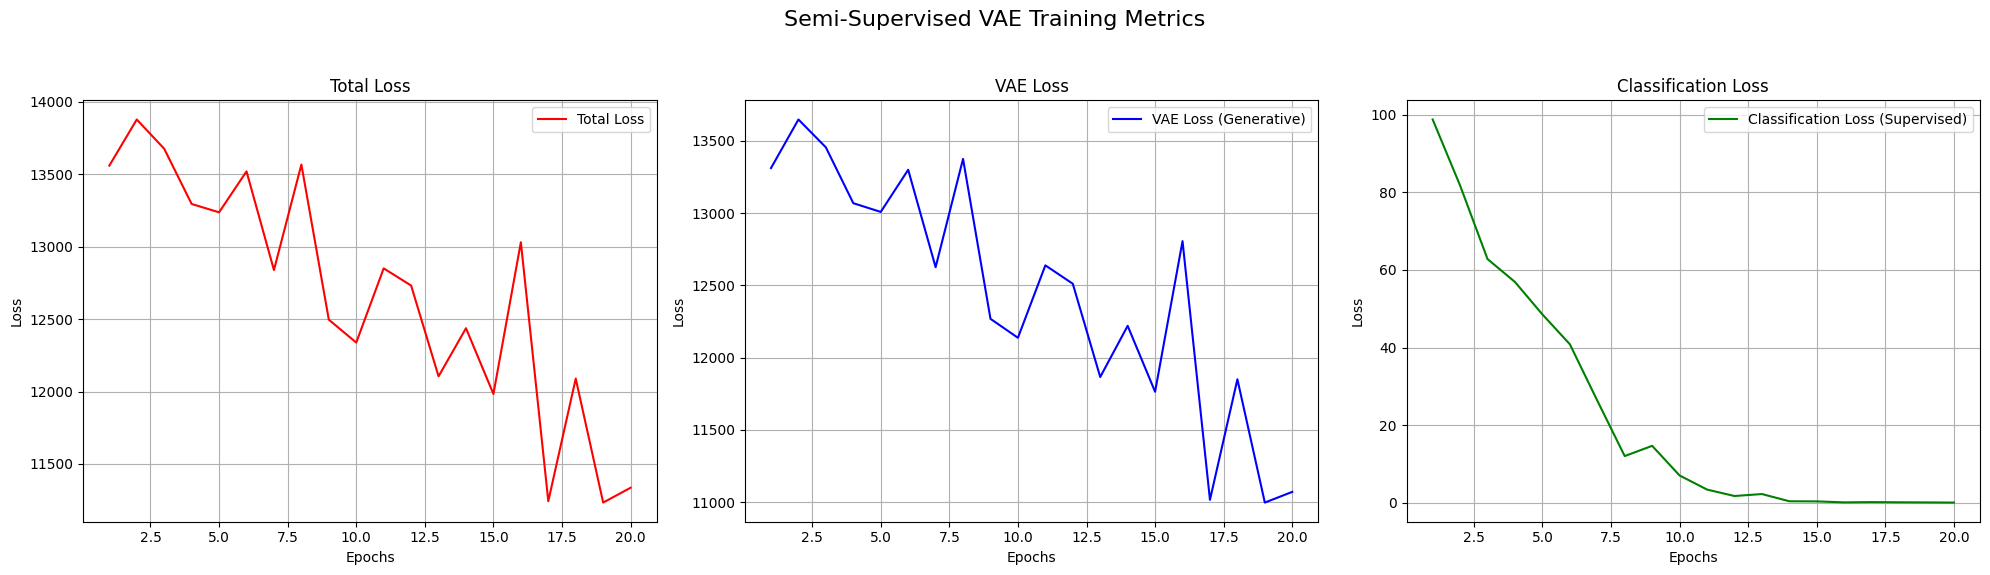

In [15]:
import matplotlib.pyplot as plt

def plot_training_metrics_subplots(history):
    """
    Plots the total, VAE, and classification losses in separate side-by-side subplots.
    """
    # Extract the loss values from the history object
    total_loss = history.history['loss']
    vae_loss = history.history['recon_loss']
    clf_loss = history.history['clf_loss']
    epochs = range(1, len(total_loss) + 1)
    
    # Create a figure with 3 subplots in a single row
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('Semi-Supervised VAE Training Metrics', fontsize=16)

    # Plot Total Loss
    ax1.plot(epochs, total_loss, 'r-', label='Total Loss')
    ax1.set_title('Total Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # Plot VAE Loss
    ax2.plot(epochs, vae_loss, 'b-', label='VAE Loss (Generative)')
    ax2.set_title('VAE Loss')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    # Plot Classification Loss
    ax3.plot(epochs, clf_loss, 'g-', label='Classification Loss (Supervised)')
    ax3.set_title('Classification Loss')
    ax3.set_xlabel('Epochs')
    ax3.set_ylabel('Loss')
    ax3.legend()
    ax3.grid(True)
    
    # Adjust layout to prevent titles from overlapping
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Call the function with the history from your model training
plot_training_metrics_subplots(history)

### Visualization of latent space

In [16]:
import numpy as np

# Prepare lists to hold the data
test_images_list = []
test_labels_list = []

print("Extracting images and labels from the test dataset...")
# Iterate through the dataset
for images, labels in labeled_test_ds:
    test_images_list.append(images.numpy())
    test_labels_list.append(labels.numpy())

# Concatenate the lists of batches into single NumPy arrays
test_images_np = np.concatenate(test_images_list, axis=0)
test_labels_np = np.concatenate(test_labels_list, axis=0)

print(f"Extracted {len(test_images_np)} images and labels.")

Extracting images and labels from the test dataset...
Extracted 249 images and labels.


2025-08-17 09:48:02.371775: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [17]:
from sklearn.manifold import TSNE

print("Generating latent vectors from the final trained encoder...")
# Use the new NumPy array of images
z_mean, _, _ = encoder.predict(test_images_np)

print("Running t-SNE... (This may take a moment)")
tsne = TSNE(n_components=2, perplexity=30.0, max_iter=1000, random_state=42)
tsne_results = tsne.fit_transform(z_mean)

print("t-SNE complete.")

Generating latent vectors from the final trained encoder...
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step

2025-08-17 09:48:02.434887: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Running t-SNE... (This may take a moment)
t-SNE complete.


/tmp/ipykernel_71480/4058007622.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap("jet", num_classes),


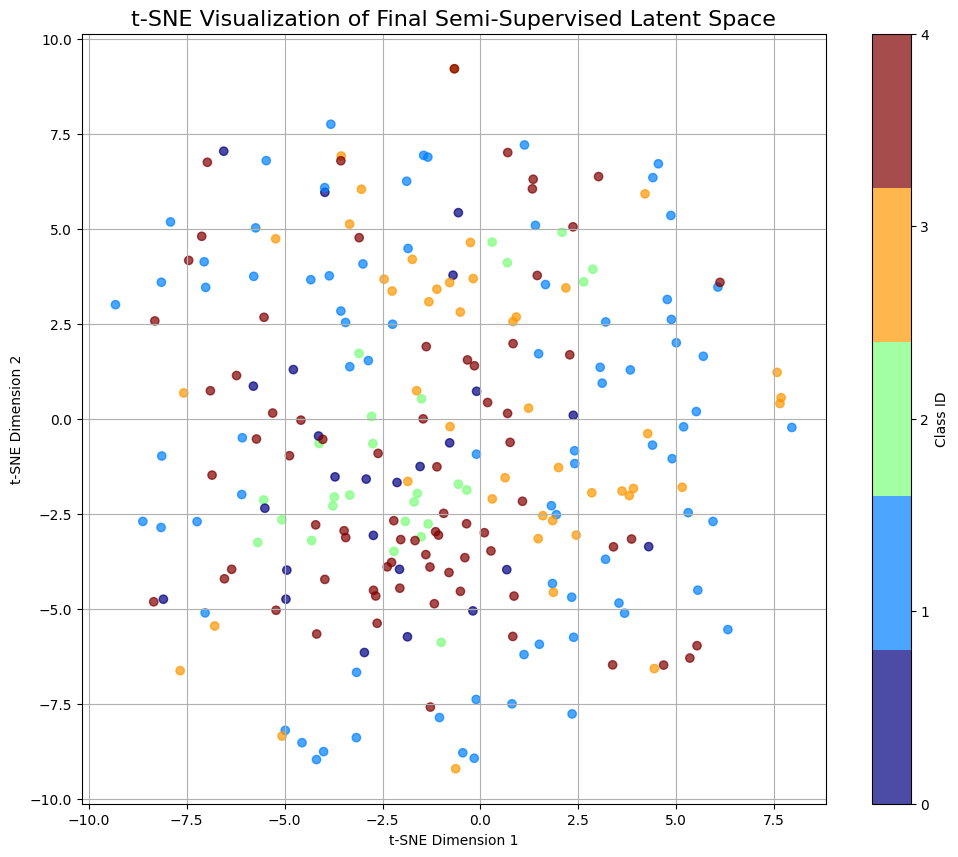

In [18]:
import matplotlib.pyplot as plt
import numpy as np

def plot_labeled_tsne_scatter(tsne_results, labels):
    """
    Creates a colored scatter plot of t-SNE results for any number of classes.
    """
    # --- CHANGE 1: Determine the number of classes dynamically ---
    num_classes = len(np.unique(labels))
    
    plt.figure(figsize=(12, 10))
    
    scatter = plt.scatter(
        tsne_results[:, 0], 
        tsne_results[:, 1], 
        c=labels, 
        # --- CHANGE 2: Use the dynamic number of classes for the colormap ---
        cmap=plt.cm.get_cmap("jet", num_classes),
        alpha=0.7
    )
    
    plt.title("t-SNE Visualization of Final Semi-Supervised Latent Space", fontsize=16)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    
    # --- CHANGE 3: Use the dynamic number of classes for the color bar ---
    cbar = plt.colorbar(scatter, ticks=range(num_classes))
    cbar.set_label("Class ID")
    
    plt.grid(True)
    plt.show()

# --- HOW TO USE ---
# Call the function with the results from the previous steps
plot_labeled_tsne_scatter(tsne_results, test_labels_np)

/tmp/ipykernel_71480/2035298744.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap("jet", num_classes), alpha=0.1)


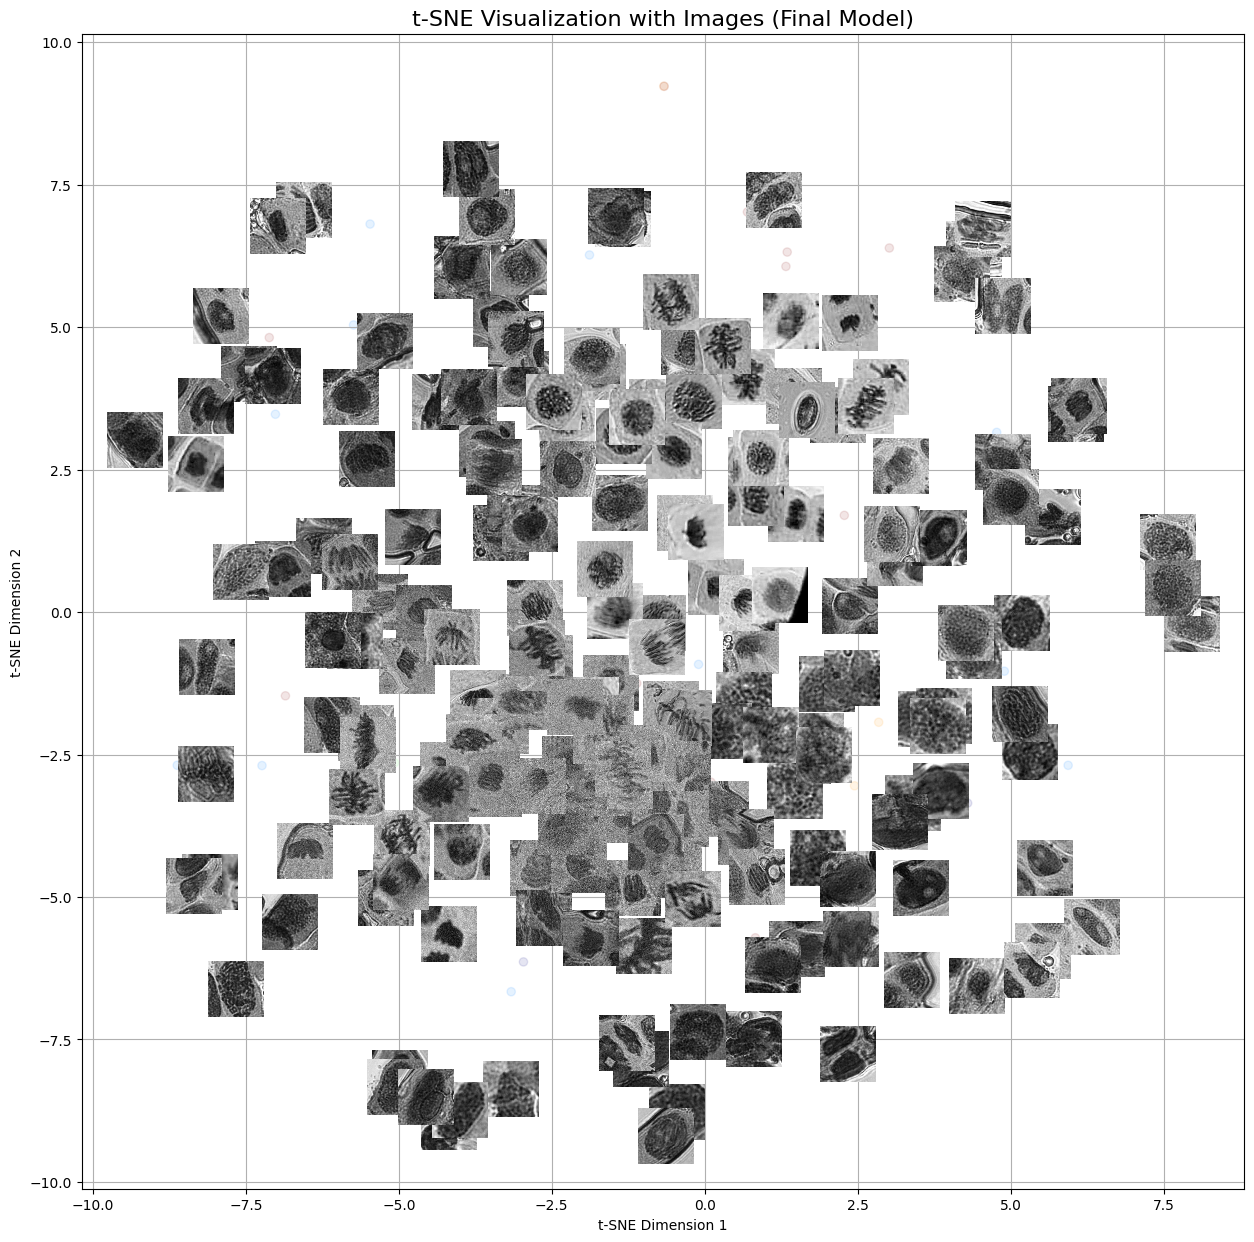

In [19]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np
import matplotlib.pyplot as plt

def plot_labeled_tsne_images(tsne_results, images, labels, zoom=0.2):
    """
    Creates a t-SNE plot with original images, adapted for any number of classes.
    """
    # Determine the number of classes dynamically
    num_classes = len(np.unique(labels))
    
    fig, ax = plt.subplots(figsize=(15, 15))
    
    # Use the dynamic number of classes for the colormap
    ax.scatter(tsne_results[:, 0], tsne_results[:, 1], c=labels, 
               cmap=plt.cm.get_cmap("jet", num_classes), alpha=0.1)
    
    # Ensure we don't try to plot more images than we have
    num_images_to_show = min(200, len(images))
    
    # Sample indices without replacement to avoid duplicates
    indices_to_show = np.random.choice(range(len(images)), num_images_to_show, replace=False)

    for i in indices_to_show:
        x, y = tsne_results[i, :]
        
        # Squeeze the channel dimension (e.g., from (200, 200, 1) to (200, 200))
        img = np.squeeze(images[i])
        
        im = OffsetImage(img, cmap='gray', zoom=zoom)
        ab = AnnotationBbox(im, (x, y), frameon=False, pad=0.0)
        ax.add_artist(ab)
        
    ax.set_title("t-SNE Visualization with Images (Final Model)", fontsize=16)
    ax.set_xlabel("t-SNE Dimension 1")
    ax.set_ylabel("t-SNE Dimension 2")
    ax.grid(True)
    plt.show()

# --- HOW TO USE ---
# Call the function with the NumPy arrays you created in the previous steps
plot_labeled_tsne_images(tsne_results, test_images_np, test_labels_np)

### Image generation

Generating archetypal image for each of 5 classes...


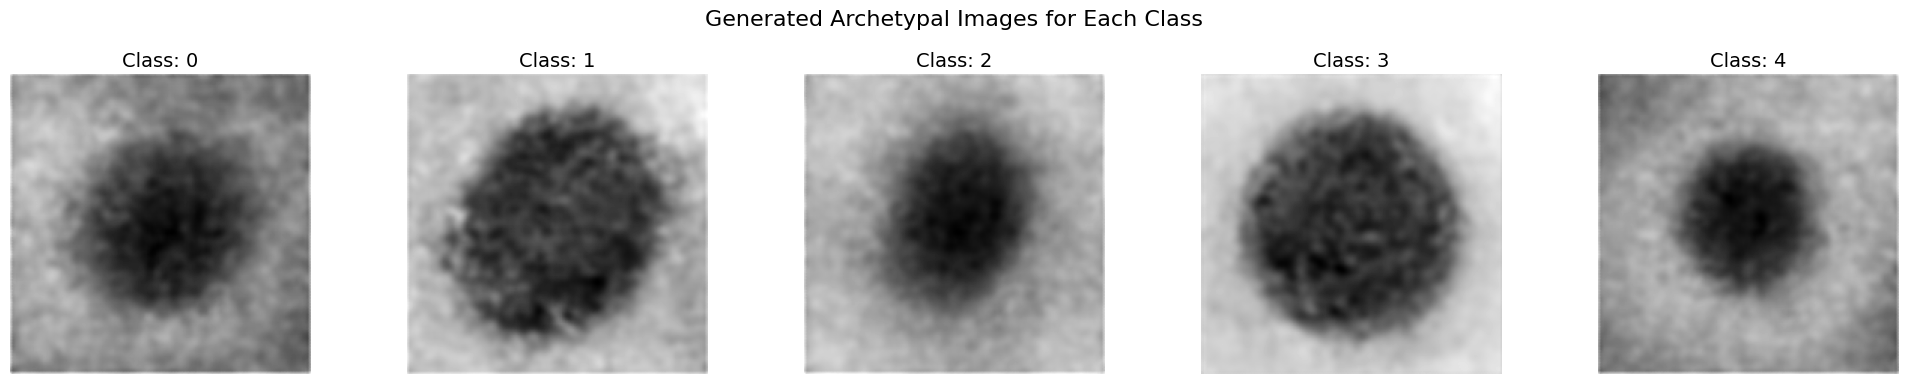

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# --- CHANGE 1: Determine the number of classes dynamically ---
class_ids = np.unique(test_labels_np)
num_classes = len(class_ids)

# A list to store the generated archetypal images
generated_images = []

print(f"Generating archetypal image for each of {num_classes} classes...")

# --- CHANGE 2: Loop through the actual class IDs ---
for i in class_ids:
    # --- CHANGE 3: Use the new NumPy arrays to find images for the current class ---
    class_images = test_images_np[test_labels_np == i]
    
    # Check if any images were found for this class
    if len(class_images) == 0:
        print(f"Warning: No test images found for class {i}. Skipping.")
        # Add a placeholder image so the plot layout isn't broken
        generated_images.append(np.zeros((INPUT_SHAPE, INPUT_SHAPE)))
        continue
    
    # Get the latent representations (z_mean) for these images
    z_mean, _, _ = encoder.predict(class_images, verbose=0)
    
    # Calculate the average latent vector for the class
    average_z = np.mean(z_mean, axis=0)
    
    # The decoder expects a batch, so we reshape the average vector
    archetype_z = np.expand_dims(average_z, axis=0)
    
    # Decode the archetypal latent vector to generate an image
    reconstructed_image = decoder.predict(archetype_z, verbose=0)
    
    # Add the generated image to our list
    generated_images.append(np.squeeze(reconstructed_image))

# --- Plotting the results (no changes needed here, as it uses num_classes) ---
fig, axes = plt.subplots(1, num_classes, figsize=(20, 4))
fig.suptitle("Generated Archetypal Images for Each Class", fontsize=16)
axes = np.atleast_1d(axes)

for i, img in enumerate(generated_images):
    # Use the actual class ID for the title
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Class: {class_ids[i]}", fontsize=14)
    axes[i].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Generating 5 images per class with temperature = 1.0...


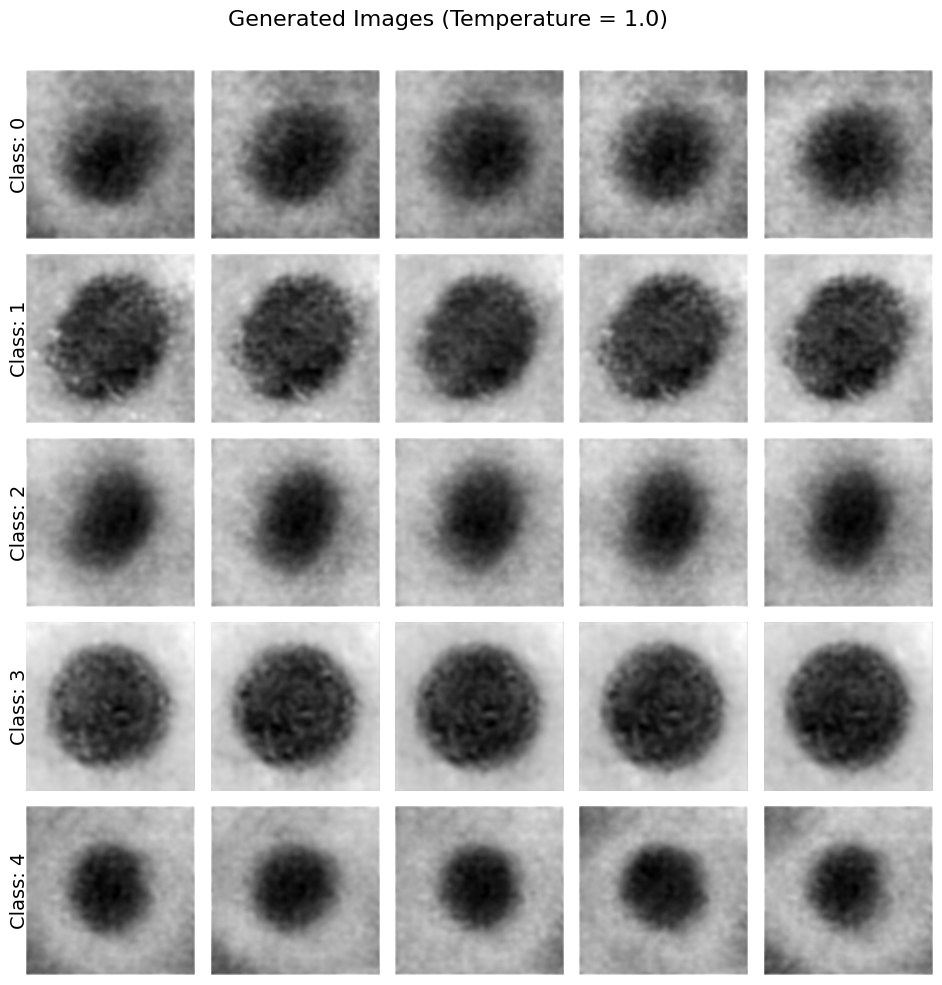

Generating 5 images per class with temperature = 2.0...


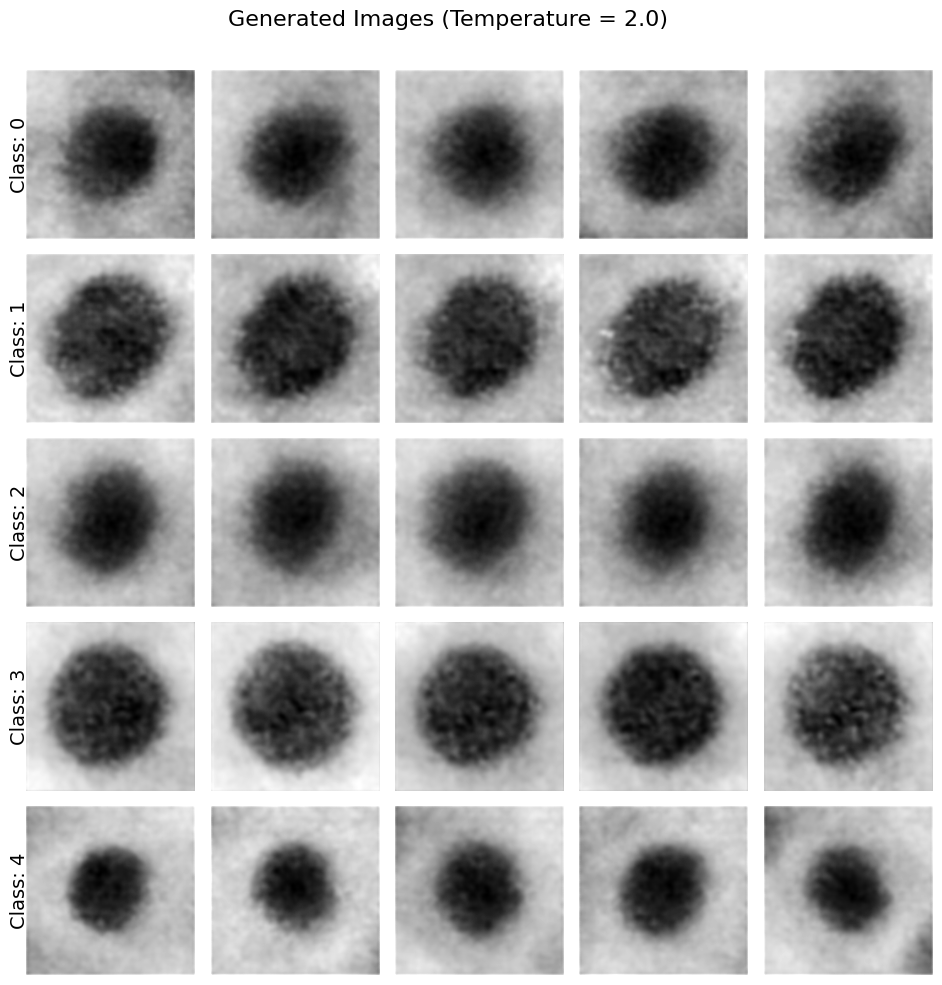

Generating 5 images per class with temperature = 4.0...


2025-08-17 09:48:07.440044: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


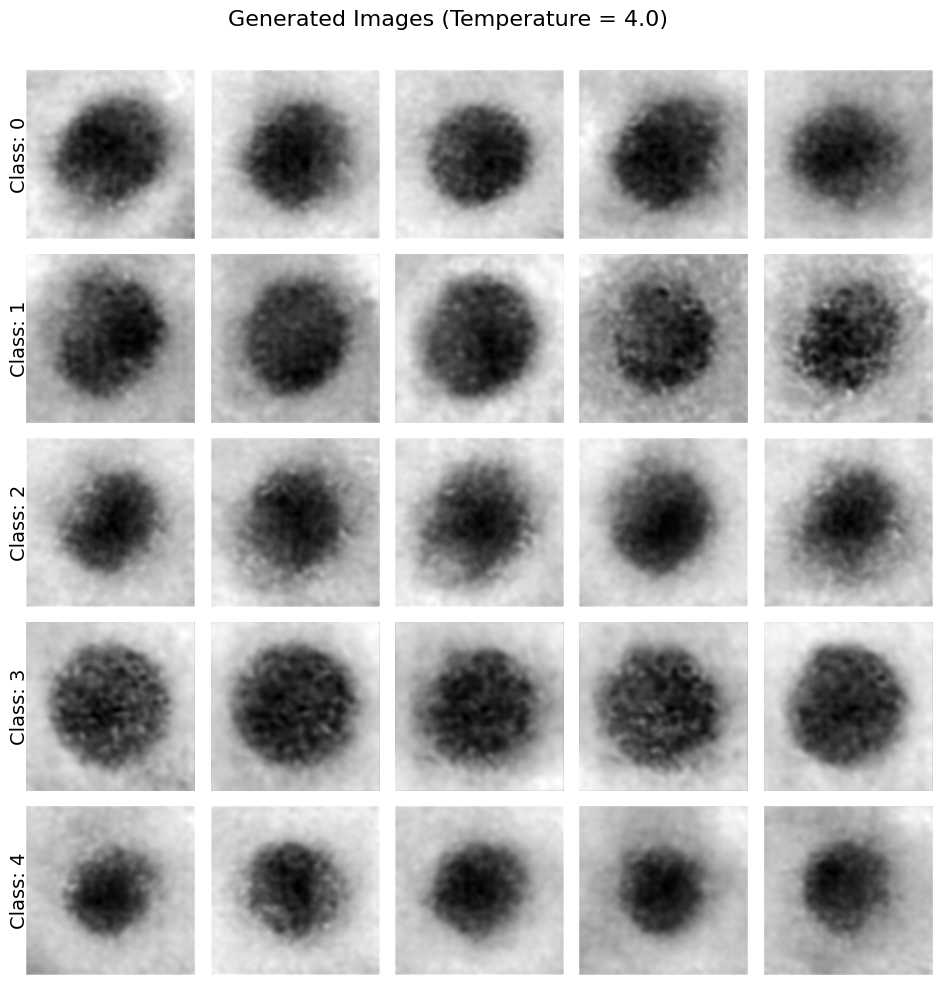

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def generate_and_plot_class_images(images, labels, temperature=1.0, samples_per_class=5):
    """
    Generates and plots diverse images for each class with a controllable temperature.
    """
    # --- CHANGE 1: Get class information dynamically from the labels array ---
    class_ids = np.unique(labels)
    num_classes = len(class_ids)
    
    # Initialize a dictionary to hold the generated images
    generated_images_dict = {cid: [] for cid in class_ids}

    print(f"Generating {samples_per_class} images per class with temperature = {temperature}...")

    # --- CHANGE 2: Loop through the actual class IDs ---
    for class_id in class_ids:
        # --- CHANGE 3: Use the provided image and label arrays for filtering ---
        class_images = images[labels == class_id]
        
        if len(class_images) == 0:
            print(f"Warning: No images found for class {class_id}. Skipping.")
            continue

        # Get latent parameters for all images in the class
        z_mean, z_log_var, _ = encoder.predict(class_images, verbose=0)
        
        # Calculate the average distribution for the class
        class_z_mean = np.mean(z_mean, axis=0)
        class_z_log_var = np.mean(z_log_var, axis=0)
        
        # Generate N samples
        for _ in range(samples_per_class):
            latent_dim = class_z_mean.shape[0]
            epsilon = tf.random.normal(shape=(1, latent_dim))
            
            standard_deviation = tf.exp(0.5 * class_z_log_var)
            z_sample = class_z_mean + temperature * standard_deviation * epsilon
            
            reconstructed_image = decoder.predict(z_sample, verbose=0)
            generated_images_dict[class_id].append(np.squeeze(reconstructed_image))

    # --- Plotting the results ---
    fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(10, num_classes * 2))
    fig.suptitle(f"Generated Images (Temperature = {temperature})", fontsize=16)
    
    # Ensure axes is always a 2D array for consistent indexing
    if num_classes == 1:
        axes = np.array([axes])
    if samples_per_class == 1:
        axes = axes.reshape(-1, 1)

    for i, class_id in enumerate(class_ids):
        for j in range(samples_per_class):
            if j < len(generated_images_dict[class_id]):
                axes[i, j].imshow(generated_images_dict[class_id][j], cmap='gray')
            axes[i, j].axis('off')
        # Add a row title with the correct class ID
        axes[i, 0].text(-20, INPUT_SHAPE / 2, f'Class: {class_id}', verticalalignment='center', rotation='vertical', fontsize=14)

    plt.tight_layout(rect=[0.05, 0, 1, 0.97])
    plt.show()

# --- HOW TO USE ---

# Call the function with your NumPy arrays and experiment with temperature
generate_and_plot_class_images(test_images_np, test_labels_np, temperature=1.0)
generate_and_plot_class_images(test_images_np, test_labels_np, temperature=2.0)
generate_and_plot_class_images(test_images_np, test_labels_np, temperature=4.0)
